In [1]:
pip install split-folders


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import splitfolders

splitfolders.ratio("Rice", output="Rice_split", seed=42, ratio=(.8, .2))


Copying files: 1500 files [00:04, 324.35 files/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r"Rice_split\train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    r"Rice_split\val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

base_model = InceptionResNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(3, activation='softmax')(x)  

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])



Found 1200 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


In [6]:
# === Antrenare ===
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
)



C:\Users\Livia\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.6149 - loss: 0.8351 - val_accuracy: 0.9633 - val_loss: 0.1473
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.9283 - loss: 0.1899 - val_accuracy: 0.9733 - val_loss: 0.1019
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.9617 - loss: 0.1473 - val_accuracy: 0.9733 - val_loss: 0.0819
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.9569 - loss: 0.1049 - val_accuracy: 0.9867 - val_loss: 0.0611
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.9743 - loss: 0.0895 - val_accuracy: 0.9733 - val_loss: 0.0724
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9766 - loss: 0.0911 - val_accuracy: 0.9767 - val_loss: 0.0542
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9848 - loss: 0.0612 - val_accuracy: 0.9800 - val_loss: 0.0557
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9774 - loss: 0.0682 - val_accuracy: 0.9900 - va

In [8]:
# === Evaluare ===
loss, acc = model.evaluate(val_generator)
print(f"Validation accuracy: {acc:}, loss: {loss:}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9760 - loss: 0.0490
Validation accuracy: 0.9766666889190674, loss: 0.05476226285099983


In [22]:
def plot(history,test_gen,train_gen,model):
    # Plotting Accuracy, val_accuracy, loss, val_loss
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax = ax.ravel()

    for i, met in enumerate(['accuracy', 'loss']):
        ax[i].plot(history.history[met])
        ax[i].plot(history.history['val_' + met])
        ax[i].set_title('Model {}'.format(met))
        ax[i].set_xlabel('epochs')
        ax[i].set_ylabel(met)
        ax[i].legend(['Train', 'Validation'])
        
    # Predict Data Test
    pred = model.predict(test_gen )
    pred = np.argmax(pred,axis=1)
    labels = (train_gen.class_indices)
    labels = dict((v,k) for k,v in labels.items())
    pred = [labels[k] for k in pred]
    
    # Classification report
    cm=confusion_matrix(test_df.Labels,pred)
    clr = classification_report(test_df.Labels, pred)
    print(clr)
    # Display 6 picture of the dataset with their labels
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 8),
                        subplot_kw={'xticks': [], 'yticks': []})

    for i, ax in enumerate(axes.flat):
        ax.imshow(plt.imread(test_df.File_Path.iloc[i+1]))
        ax.set_title(f"True: {test_df.Labels.iloc[i+1]}\nPredicted: {pred[i+1]}")
    plt.tight_layout()
    plt.show()
        
    return history

In [ ]:
import pandas as pd
import numpy as np
import os


filenames = val_generator.filenames
labels = val_generator.classes
class_names = list(val_generator.class_indices.keys())

test_df = pd.DataFrame({
    'File_Path': [os.path.join(val_generator.directory, fname) for fname in filenames],
    'Labels': [class_names[label] for label in labels]
})



In [26]:
print(test_df)

                                             File_Path     Labels
0    C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...    Arborio
1    C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...    Arborio
2    C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...    Arborio
3    C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...    Arborio
4    C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...    Arborio
..                                                 ...        ...
295  C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...  Karacadag
296  C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...  Karacadag
297  C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...  Karacadag
298  C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...  Karacadag
299  C:\Users\Livia\Desktop\FCIM\IA\Rice_split\val\...  Karacadag

[300 rows x 2 columns]


In [28]:
import pandas as pd
import numpy as np

def get_true_labels_and_paths(generator):
    image_paths = []
    labels = []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        batch_filenames = generator.filenames[i * generator.batch_size : (i+1) * generator.batch_size]
        for j, fname in enumerate(batch_filenames):
            image_paths.append(os.path.join(generator.directory, fname))
            label_index = np.argmax(y_batch[j])  # one-hot -> index
            labels.append(label_index)
    
    # Convertim la nume clase
    class_names = list(generator.class_indices.keys())
    label_names = [class_names[i] for i in labels]

    return pd.DataFrame({'File_Path': image_paths, 'Labels': label_names})

test_df = get_true_labels_and_paths(val_generator)


10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
              precision    recall  f1-score   support

     Arborio       1.00      0.93      0.96       100
     Basmati       1.00      1.00      1.00       100
   Karacadag       0.93      1.00      0.97       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



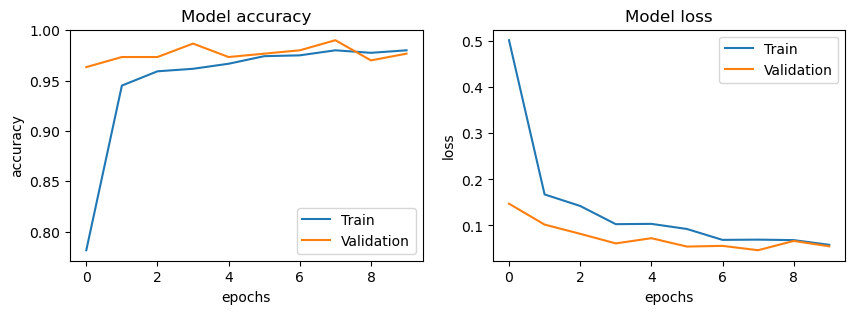

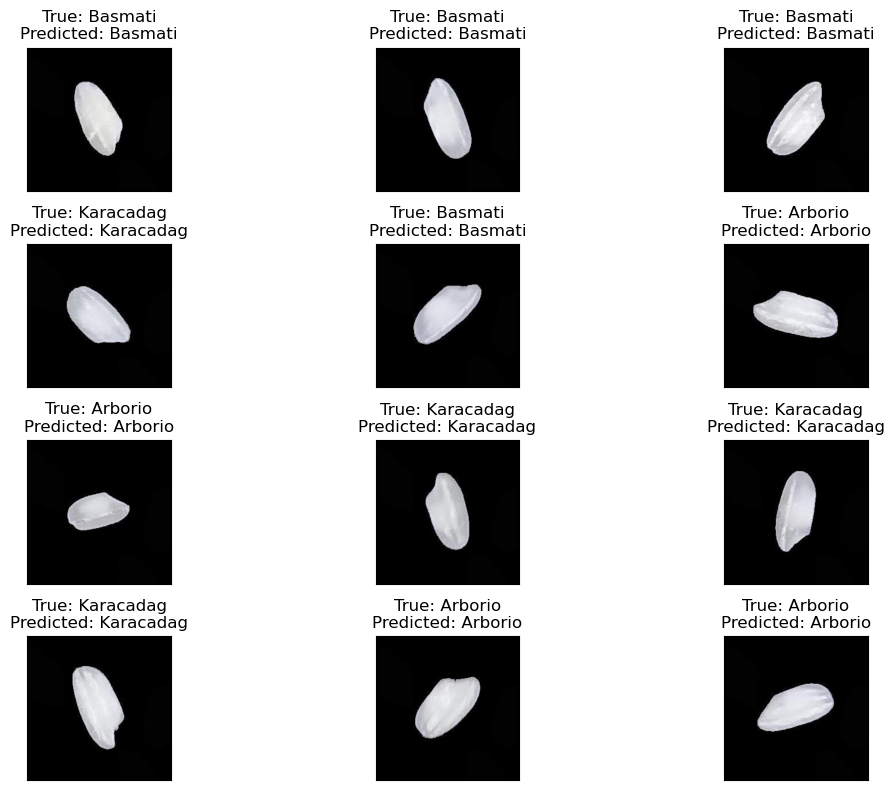

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

history_ResNet= plot(history,val_generator,train_generator, model)
